In [5]:
%reset -f

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import CubicSpline

torch.set_default_dtype(torch.float64)

## MAIN SOLVER Forward Difference 

In [26]:

def set_BCs(T):
    T[0]  = T[2]
    T[-1] = T[-2] ** 2 / max(T[-3].item(), 1e-40)

def avg_2_center(T, m): # converting cell average to cell center value
    Tc = T.clone()
    Tc[m] = (8*T[m]-T[m-1]-T[m+1])/6
    return Tc

def solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True):
    """
    Solve the two-layer heat equation from t=0 to t=tf.
    nt_skip = smallest integer s.t.  M * delta > tf,  delta = nt_skip * dt.
    Solution saved every nt_skip fine steps — no resampling.
    Returns: z (nz+1,), t_out (n_out+1,), U_coarse (nz+1, n_out+1), nt_skip, delta
    """
    dz = Lz / nz
    z  = torch.arange(-1, nz + 2, device=device) * dz
    m  = torch.searchsorted(z, z_dis - 0.5 * dz, right=True).item()
    if verbose:
        print(f'device: {device},  nz={nz},  tf={tf},  M={M}')
        print(f'Interface alignment error: {z[m].item() - z_dis:.2e}')
    k_iL = 8 * k1 * k2 / (k1 + 7 * k2)
    k_iR = 8 * k1 * k2 / (7 * k1 + k2)
    kh   = torch.where(
        z[:-1] < z_dis - 0.5 * dz,
        torch.tensor(k1, device=device),
        torch.tensor(k2, device=device),
    )
    kh[m - 1] = k_iL
    kh[m]     = k_iR
    #
    # find nt_skip, nt_num, t_out, U_out
    dt_stab = 0.5 * (dz ** 2) / max(k1, k2) # stable numerical time step
    dt_want = tf/M
    nt_skip = int(np.ceil(dt_want/dt_stab))
    dt = dt_want/nt_skip
    dM = 5 # set dM > 0 to intentionally go beyond tf
    nt_num = (M+dM)*nt_skip
    delta   = nt_skip * dt
    t_out = torch.arange(0,M+dM+1)*delta
    U_out = torch.zeros(nz+1, M+dM+1, device=device)
    if verbose:
        print(f'dt_stab={dt_stab:.4e}  dt={dt:.4e}  nt_num={nt_num}  tf_num = {nt_num*dt}')
        print(f'nt_skip={nt_skip}  delta={delta:.6f}')
    #
    source    = Pda * torch.exp(-z[1:-1])
    source[0] = Pda * torch.exp(-z[2]/4)
    T = torch.zeros(nz + 3, device=device)
    i_save = 0 # U_out[:,0]=0 is already good.
    for step in range(1, nt_num+1):
        set_BCs(T)
        Jh      = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source
        if step % nt_skip == 0:
            i_save += 1
            U_out[:,i_save] = avg_2_center(T, m)[1:-1]
            # we save cell center value, not cell average!!!
    set_BCs(T)
    T[m] = T[m] + (2 * T[m] - T[m - 1] - T[m + 1]) / 6
    print(f't_out.shape = {t_out.shape},  U_out.shape = {U_out.shape}\n')
    return {'z': z[1:-1], 't_out': t_out, 'U_out': U_out, 'nt_skip': nt_skip, 'delta': delta}

In [27]:
k1, k2  = 1.0, 2.0
z_dis   = 1.0
Pda     = 1.0
Lz      = 16.0
tf      = 20.0
device  = 'cuda' if torch.cuda.is_available() else 'cpu'



In [28]:
%%time 
nz = 640; M = 320
R= solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True)


device: cuda,  nz=640,  tf=20.0,  M=320
Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  dt=1.5625e-04  nt_num=130000  tf_num = 20.3125
nt_skip=400  delta=0.062500
t_out.shape = torch.Size([326]),  U_out.shape = torch.Size([641, 326])

CPU times: user 45.2 s, sys: 33.6 ms, total: 45.2 s
Wall time: 45.2 s


In [39]:
def pt_2d_interpolation(z, t, U, **kwargs):
    """
    PyTorch-compatible 2D interpolator using RectBivariateSpline.

    Parameters
    ----------
    z  : (nz+1,)           spatial grid  (strictly increasing)
    t  : (n_t_out,)        time grid     (strictly increasing)
    U  : (nz+1, n_t_out)   U[i, j] = solution at (z[i], t[j])
    **kwargs               passed to RectBivariateSpline
                           e.g. kx=3, ky=3, s=0  (cubic, exact)
                                kx=1, ky=1, s=0  (linear, exact)

    Returns
    -------
    interp : callable
        interp(z_q, t_q)           ->  U(z_q, t_q)
        interp(z_q, t_q, dx=1)     ->  dU/dz(z_q, t_q)
        interp(z_q, t_q, dy=1)     ->  dU/dt(z_q, t_q)
    """
    defaults = {'kx': 3, 'ky': 3, 's': 0}   # cubic exact-fit by default
    defaults.update(kwargs)

    rbs = RectBivariateSpline(
        z.cpu().numpy(),
        t.cpu().numpy(),
        U.cpu().numpy(),
        **defaults,
    )

    def interp(z_q, t_q, **ev_kwargs):
        # Ensure inputs are tensors with correct dtype and on CPU for numpy conversion
        z_q = torch.as_tensor(z_q, dtype=U.dtype)
        t_q = torch.as_tensor(t_q, dtype=U.dtype)
        z_q, t_q = torch.broadcast_tensors(z_q, t_q)
        # Move to CPU for scipy, convert to numpy, evaluate, then move back to original device
        vals = rbs.ev(z_q.cpu().numpy(), t_q.cpu().numpy(), **ev_kwargs)
        return torch.from_numpy(vals).to(device=U.device, dtype=U.dtype)

    interp._rbs = rbs   # expose underlying object if needed
    return interp


def pt_2d_interp_piecewise(z, t, U, z_dis, **kwargs):
    """
    Piecewise cubic RectBivariateSpline — separate spline each side of z_dis.

    Avoids Gibbs-like overshoot that a single cubic spline produces when
    the derivative is discontinuous at the interface.

    Falls back to a single full cubic if either side has fewer than
    kx+1 points (can happen with aggressive downsampling strides).
    """
    defaults = {'kx': 3, 'ky': 3, 's': 0}
    defaults.update(kwargs)
    min_pts = defaults['kx'] + 1   # need at least kx+1 points per side

    m = torch.searchsorted(
        z, torch.tensor(z_dis, device=z.device)
    ).item()

    n_left  = m + 1          # z[:m+1] has m+1 points
    n_right = len(z) - m    # z[m:]   has len(z)-m points

    # graceful fallback when a side is too narrow for the chosen spline degree
    if n_left < min_pts or n_right < min_pts:
        print(f'[interp_pw] warning: {n_left} left / {n_right} right points '
              f'(need ≥{min_pts} per side). Falling back to full cubic.')
        return pt_2d_interpolation(z, t, U, **defaults)

    interp_L = pt_2d_interpolation(z[:m+1], t, U[:m+1, :], **defaults)
    interp_R = pt_2d_interpolation(z[m:],   t, U[m:,   :], **defaults)

    def interp(z_q, t_q, **ev_kwargs):
        # Ensure everything is on the correct device
        device = z.device
        z_q = torch.as_tensor(z_q, dtype=z.dtype, device=device)
        t_q = torch.as_tensor(t_q, dtype=t.dtype, device=device)
        z_q, t_q = torch.broadcast_tensors(z_q, t_q)
        out  = torch.zeros_like(z_q, device=device)
        mask = z_q <= z_dis
        if mask.any():
            result_L = interp_L(z_q[mask],  t_q[mask],  **ev_kwargs)
            out[mask]  = result_L.to(device=device, dtype=out.dtype)
        if (~mask).any():
            result_R = interp_R(z_q[~mask], t_q[~mask], **ev_kwargs)
            out[~mask] = result_R.to(device=device, dtype=out.dtype)
        return out

    return interp

In [40]:
# interpolation function
interp_pw  = pt_2d_interp_piecewise(
            R['z'], R['t_out'], R['U_out'], z_dis, kx=3, ky=3, s=0
        )

In [41]:
# Keep both tensors on the same device before meshgrid
z_device = R['z'].device
t_device = R['t_out'].device

# Move to same device if needed
z_grid = R['z'].to(device)
t_grid = R['t_out'].to(device)
z_d, t_d = torch.meshgrid(z_grid, t_grid, indexing='ij')

# Evaluate interpolator and move result to CPU for comparison
U_interp = interp_pw(z_d, t_d)
err1 = torch.abs(R['U_out'] - U_interp)

t =  0.0000: max error = 1.601458e-18
t =  5.0625: max error = 8.881784e-16
t = 10.1875: max error = 8.881784e-16
t = 15.2500: max error = 1.332268e-15
t = 20.3125: max error = 1.332268e-15


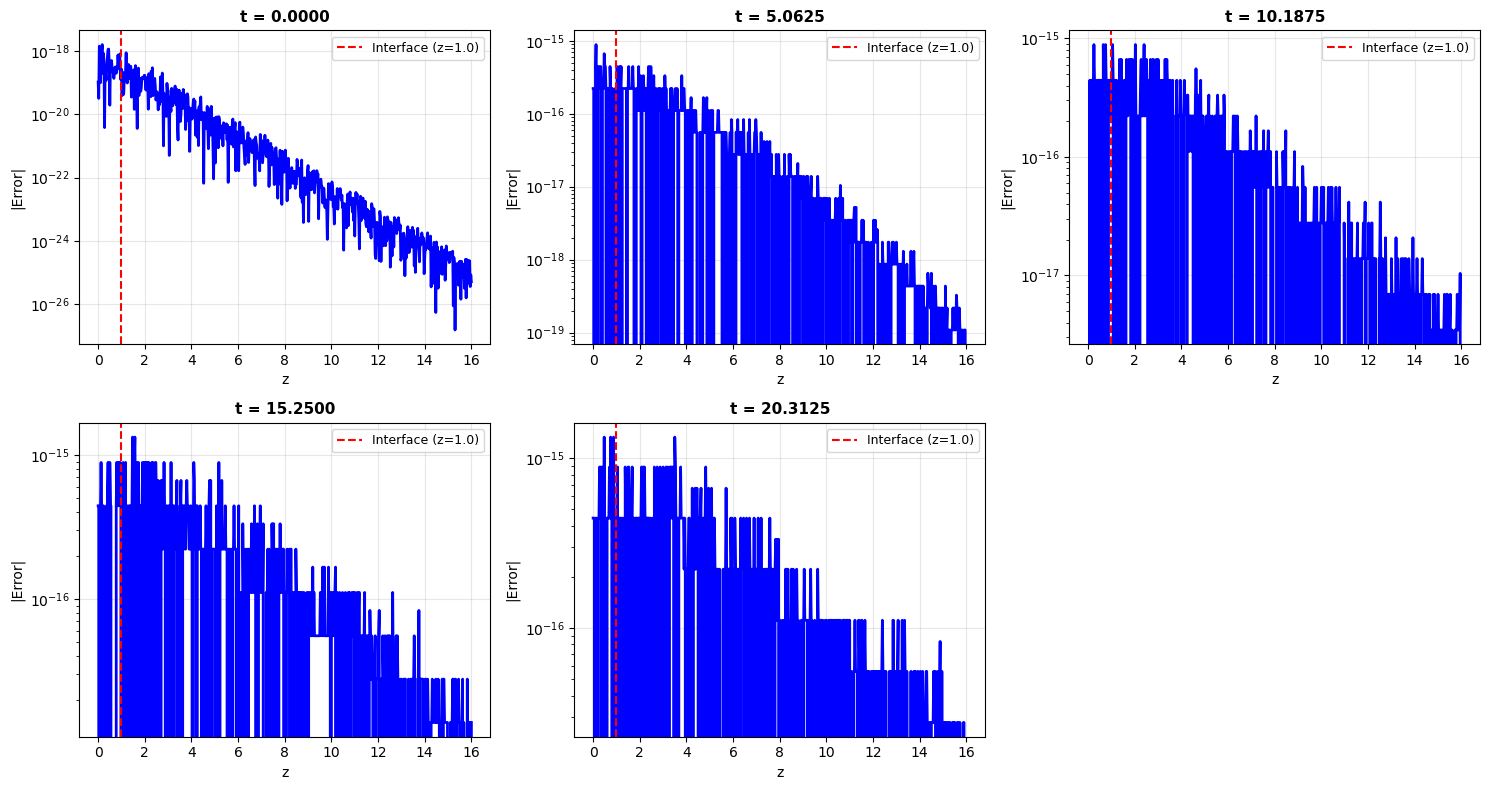


Overall statistics:
Max error (all times): 2.220446e-15
Mean error: 1.086113e-16
Median error: 1.387779e-17


In [44]:
# CELL 1: Plot error vs z at different times
import matplotlib.pyplot as plt

z = R['z'].cpu().numpy()
t_out = R['t_out'].cpu().numpy()
err = err1.cpu().numpy()  # (nz+1, n_out+1)

# Select time indices to plot (including t=0 and t~=tf)
time_indices = [
    0,                          # t = 0
    len(t_out) // 4,            # t ≈ tf/4
    len(t_out) // 2,            # t ≈ tf/2
    3 * len(t_out) // 4,        # t ≈ 3*tf/4
    len(t_out) - 1              # t ≈ tf
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax_idx, t_idx in enumerate(time_indices):
    ax = axes[ax_idx]
    t_val = t_out[t_idx]
    error_at_t = err[:, t_idx]
    
    ax.semilogy(z, error_at_t, 'b-', linewidth=2)
    ax.axvline(z_dis, color='r', linestyle='--', linewidth=1.5, label=f'Interface (z={z_dis})')
    ax.set_xlabel('z', fontsize=10)
    ax.set_ylabel('|Error|', fontsize=10)
    ax.set_title(f't = {t_val:.4f}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # Print max error at this time
    max_err = error_at_t.max()
    print(f't = {t_val:7.4f}: max error = {max_err:.6e}')

# Hide the last unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('error_vs_z_different_times.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nOverall statistics:')
print(f'Max error (all times): {err.max():.6e}')
print(f'Mean error: {err.mean():.6e}')
print(f'Median error: {np.median(err):.6e}')

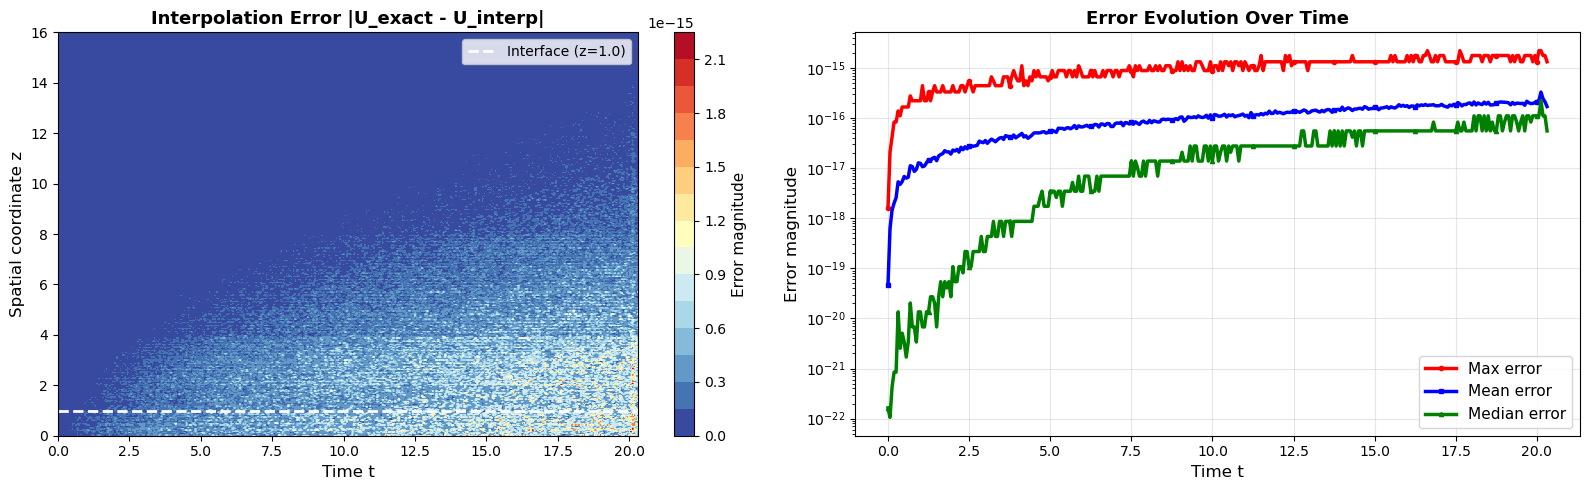

Error statistics by time:
t		Max Error	 Mean Error	 Median Error
----------------------------------------------------------------------
 0.0000		1.601458e-18	4.595334e-20	1.639016e-22
 5.0625		8.881784e-16	5.687613e-17	3.469447e-18
10.1875		8.881784e-16	1.094202e-16	1.387779e-17
15.2500		1.332268e-15	1.600167e-16	5.551115e-17
20.3125		1.332268e-15	1.699542e-16	5.551115e-17


In [45]:
# CELL 2: 2D heatmap of error over (z, t) domain + error evolution over time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left plot: 2D heatmap
Z, T = np.meshgrid(z, t_out, indexing='ij')
contour = ax1.contourf(T, Z, err, levels=20, cmap='RdYlBu_r')
ax1.axhline(z_dis, color='white', linestyle='--', linewidth=2, label=f'Interface (z={z_dis})')
ax1.set_xlabel('Time t', fontsize=12)
ax1.set_ylabel('Spatial coordinate z', fontsize=12)
ax1.set_title('Interpolation Error |U_exact - U_interp|', fontsize=13, fontweight='bold')
cbar = plt.colorbar(contour, ax=ax1)
cbar.set_label('Error magnitude', fontsize=11)
ax1.legend(fontsize=10, loc='upper right')

# Right plot: Error metrics over time
max_err_t = np.max(err, axis=0)  # max error at each time
mean_err_t = np.mean(err, axis=0)  # mean error at each time
median_err_t = np.median(err, axis=0)  # median error at each time

ax2.semilogy(t_out, max_err_t, 'r-', linewidth=2.5, label='Max error', marker='o', markersize=3, markevery=20)
ax2.semilogy(t_out, mean_err_t, 'b-', linewidth=2.5, label='Mean error', marker='s', markersize=3, markevery=20)
ax2.semilogy(t_out, median_err_t, 'g-', linewidth=2.5, label='Median error', marker='^', markersize=3, markevery=20)
ax2.set_xlabel('Time t', fontsize=12)
ax2.set_ylabel('Error magnitude', fontsize=12)
ax2.set_title('Error Evolution Over Time', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('error_heatmap_and_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Error statistics by time:')
print('t\t\tMax Error\t Mean Error\t Median Error')
print('-' * 70)
for i in [0, len(t_out)//4, len(t_out)//2, 3*len(t_out)//4, len(t_out)-1]:
    print(f'{t_out[i]:7.4f}\t\t{max_err_t[i]:.6e}\t{mean_err_t[i]:.6e}\t{median_err_t[i]:.6e}')

Original grid: nz=641, nt=326
Coarse grid: nz=161, nt=82
Coarse solution shape: (161, 82)

Two-level interpolation errors:
Max error: 5.522141e-03
Mean error: 1.181565e-05
Median error: 4.961563e-10

Direct interpolation errors (for reference):
Max error: 2.220446e-15
Mean error: 1.086113e-16
Median error: 1.387779e-17


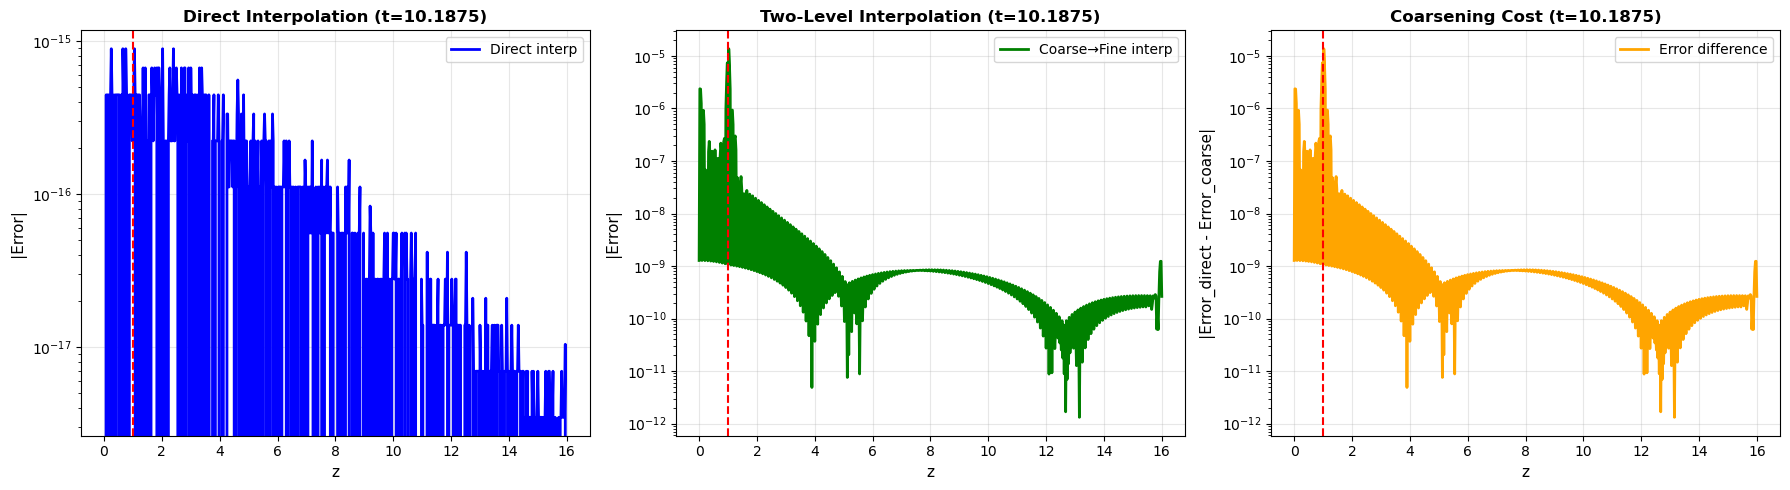

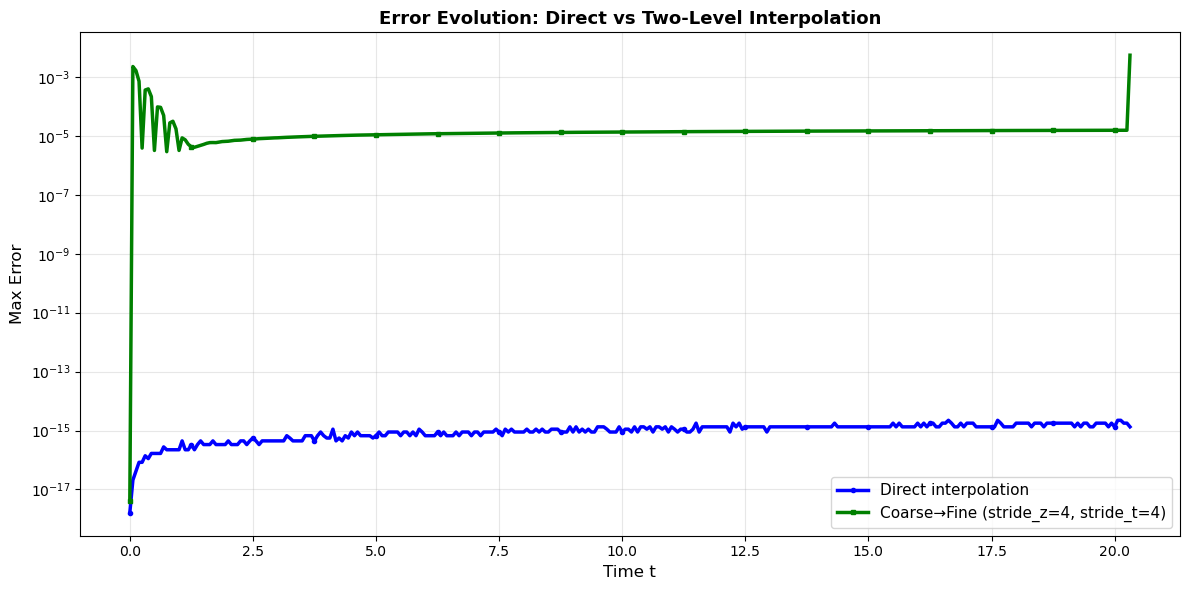

In [49]:
# Create coarse grid from original data using first interpolator
# Then create second interpolator from coarse grid



# Define coarse grid (e.g., stride=4 in spatial, stride=8 in time)
stride_z = 4
stride_t = 4

z_np = R['z'].cpu().numpy()
t_np = R['t_out'].cpu().numpy()
z_coarse = z_np[::stride_z]
t_coarse = t_np[::stride_t]

print(f'Original grid: nz={len(z_np)}, nt={len(t_np)}')
print(f'Coarse grid: nz={len(z_coarse)}, nt={len(t_coarse)}')

# Convert to tensors on the same device
z_coarse_t = torch.tensor(z_coarse, dtype=torch.float64, device=device)
t_coarse_t = torch.tensor(t_coarse, dtype=torch.float64, device=device)

# Create meshgrid with both on same device
Z_coarse, T_coarse = torch.meshgrid(z_coarse_t, t_coarse_t, indexing='ij')

# Sample solution at coarse grid points using first interpolator
U_coarse = interp_pw(Z_coarse, T_coarse).cpu().numpy()

print(f'Coarse solution shape: {U_coarse.shape}')

# Create second interpolator from coarse grid
U_coarse_t = torch.tensor(U_coarse, dtype=torch.float64, device=device)
interp_pw_coarse = pt_2d_interp_piecewise(
    z_coarse_t, t_coarse_t, U_coarse_t,
    z_dis, kx=3, ky=3, s=0
)

# Evaluate second interpolator on original grid (both on same device)
Z_orig, T_orig = torch.meshgrid(R['z'].to(device), R['t_out'].to(device), indexing='ij')
U_interp_from_coarse = interp_pw_coarse(Z_orig, T_orig).cpu().numpy()

# Compare: original vs coarse->fine interpolation
err_two_level = np.abs(R['U_out'].cpu().numpy() - U_interp_from_coarse)

print(f'\nTwo-level interpolation errors:')
print(f'Max error: {err_two_level.max():.6e}')
print(f'Mean error: {err_two_level.mean():.6e}')
print(f'Median error: {np.median(err_two_level):.6e}')

# Compare with direct interpolation
print(f'\nDirect interpolation errors (for reference):')
print(f'Max error: {err.max():.6e}')
print(f'Mean error: {err.mean():.6e}')
print(f'Median error: {np.median(err):.6e}')

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Time slice at t ≈ tf/2
t_mid = len(t_out) // 2

# Direct interpolation error
axes[0].semilogy(z, err[:, t_mid], 'b-', linewidth=2, label='Direct interp')
axes[0].axvline(z_dis, color='r', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('z', fontsize=11)
axes[0].set_ylabel('|Error|', fontsize=11)
axes[0].set_title(f'Direct Interpolation (t={t_out[t_mid]:.4f})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Two-level interpolation error
axes[1].semilogy(z, err_two_level[:, t_mid], 'g-', linewidth=2, label='Coarse→Fine interp')
axes[1].axvline(z_dis, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('z', fontsize=11)
axes[1].set_ylabel('|Error|', fontsize=11)
axes[1].set_title(f'Two-Level Interpolation (t={t_out[t_mid]:.4f})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Difference between the two
err_diff = np.abs(err - err_two_level)
axes[2].semilogy(z, err_diff[:, t_mid], 'orange', linewidth=2, label='Error difference')
axes[2].axvline(z_dis, color='r', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('z', fontsize=11)
axes[2].set_ylabel('|Error_direct - Error_coarse|', fontsize=11)
axes[2].set_title(f'Coarsening Cost (t={t_out[t_mid]:.4f})', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig('two_level_interpolation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Time evolution of errors
max_err_direct = np.max(err, axis=0)
max_err_two_level = np.max(err_two_level, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.semilogy(t_out, max_err_direct, 'b-', linewidth=2.5, label='Direct interpolation', marker='o', markersize=3, markevery=20)
ax.semilogy(t_out, max_err_two_level, 'g-', linewidth=2.5, label=f'Coarse→Fine (stride_z={stride_z}, stride_t={stride_t})', marker='s', markersize=3, markevery=20)
ax.set_xlabel('Time t', fontsize=12)
ax.set_ylabel('Max Error', fontsize=12)
ax.set_title('Error Evolution: Direct vs Two-Level Interpolation', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('two_level_error_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

Original grid: nz=641, nt=326 → Total: 208966 points
Fine grid: nz=1281, nt=651 → Total: 833931 points
Coarse grid: nz=161, nt=82 → Total: 13202 points

Evaluating first (direct) interpolator on fine grid...
Evaluating second (coarse-based) interpolator on fine grid...
Fine interpolation shape: (1281, 651)

Comparison on fine grid:
Max difference: 5.522287e-03
Mean difference: 9.100177e-06
Median difference: 5.812115e-10
L2 norm of difference: 1.560713e-01


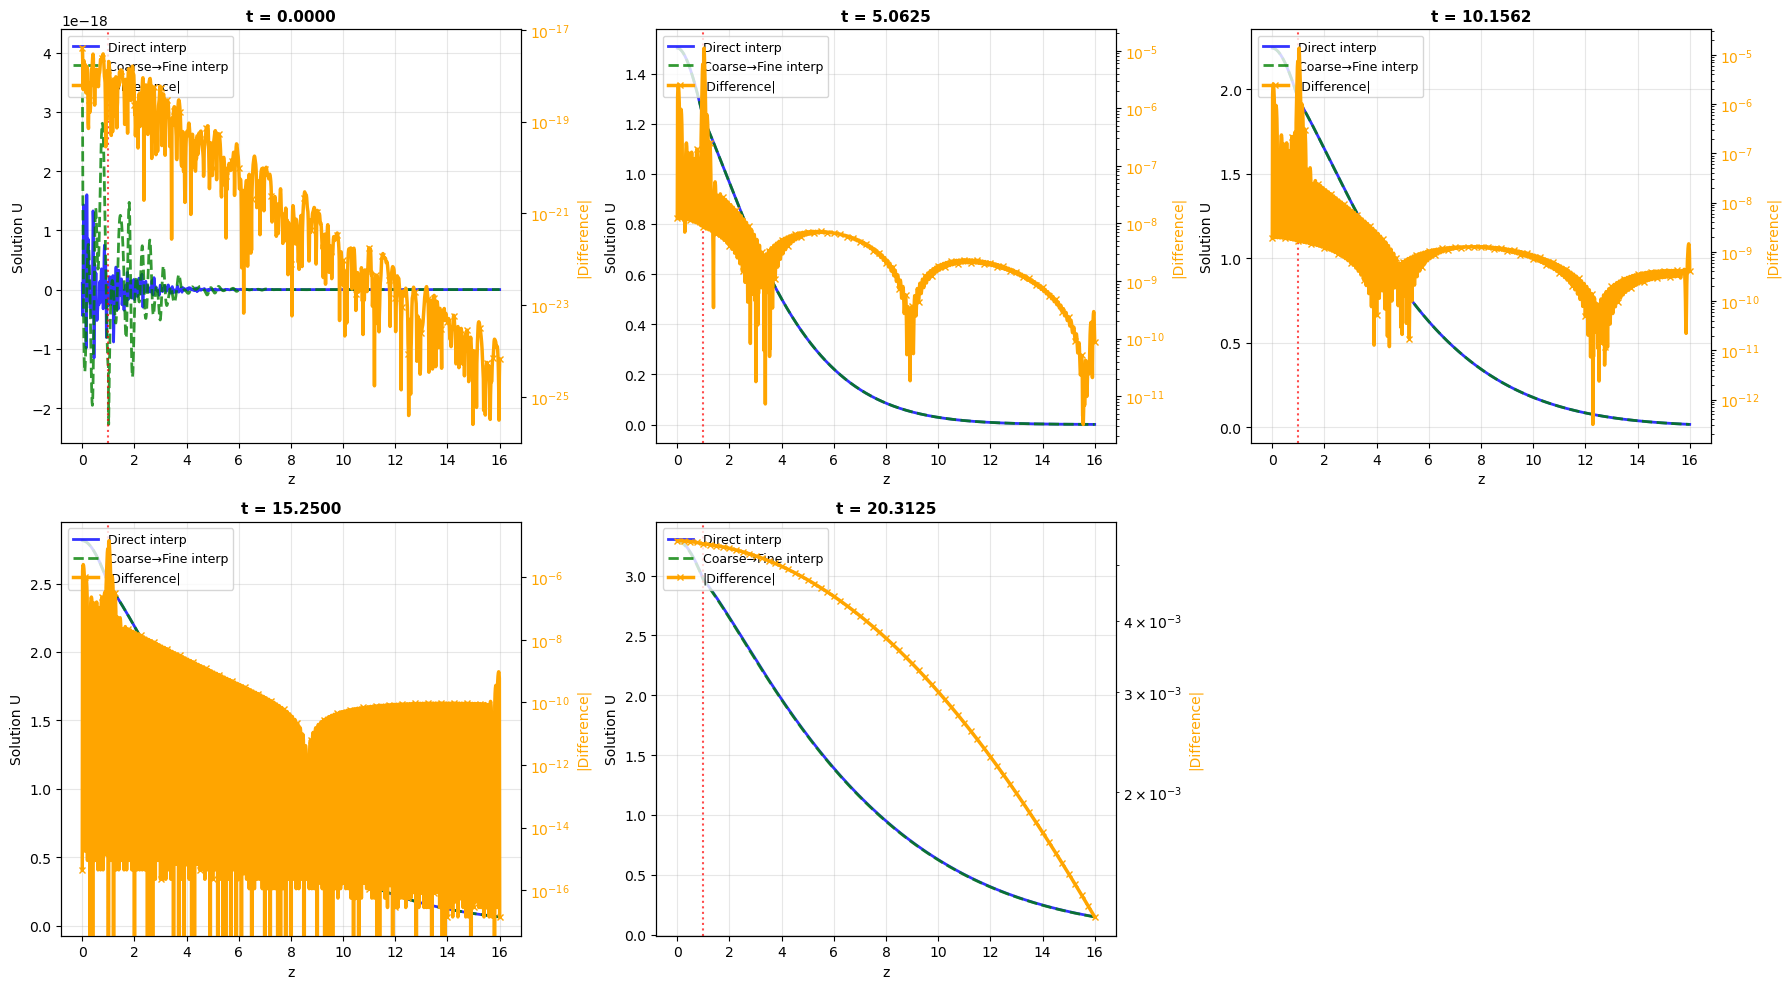

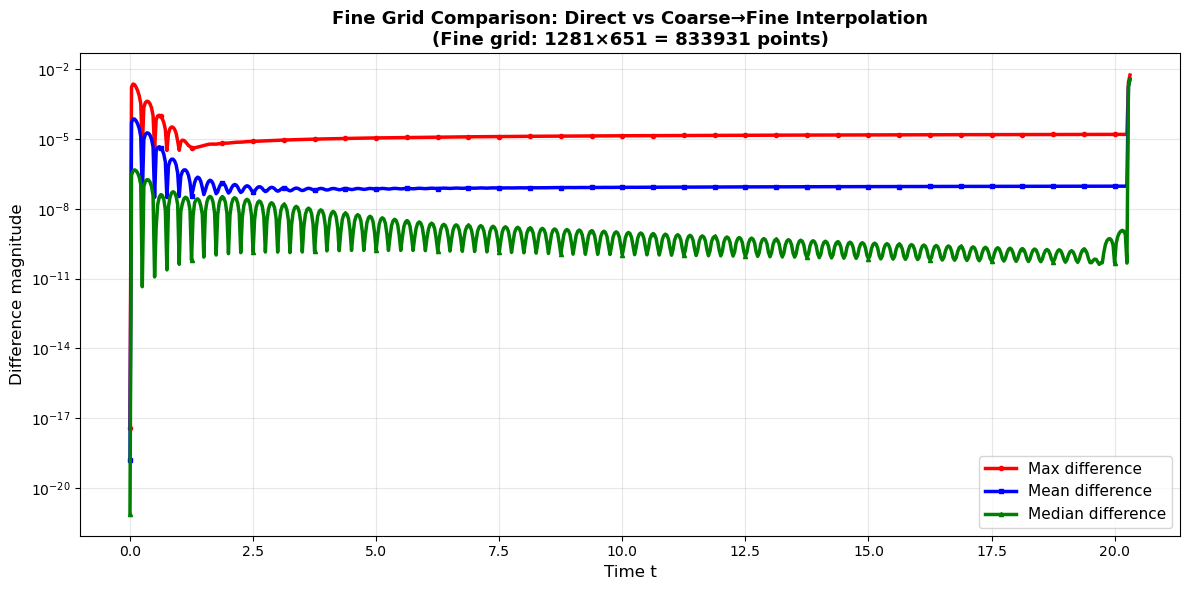

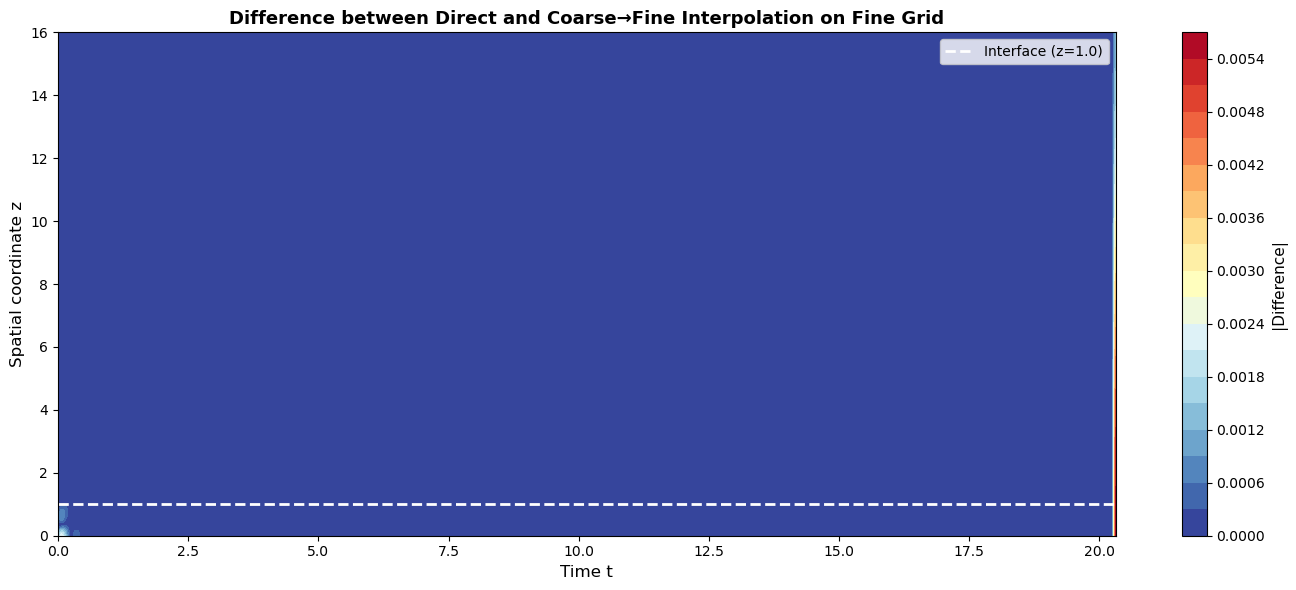


SUMMARY: Fine Grid Evaluation
Fine grid resolution: 1281 × 651 = 833,931 points
Coarse grid resolution: 161 × 82 = 13,202 points
Original grid resolution: 641 × 326 = 208,966 points

Difference statistics (Direct vs Coarse→Fine):
  Max:    5.522287e-03
  Mean:   9.100177e-06
  Median: 5.812115e-10
  L2:     1.560713e-01


In [50]:
# Evaluate first interpolation on a fine grid and compare with double coarse interpolation

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Create fine grid (finer than original)
# Original: nz=641, nt=326
# Fine: increase by factor of 2 in each direction
fine_factor_z = 2
fine_factor_t = 2

z_np = R['z'].cpu().numpy()
t_np = R['t_out'].cpu().numpy()

# Create finer grid via linear spacing
z_min, z_max = z_np.min(), z_np.max()
t_min, t_max = t_np.min(), t_np.max()

n_fine_z = (len(z_np) - 1) * fine_factor_z + 1
n_fine_t = (len(t_np) - 1) * fine_factor_t + 1

z_fine = np.linspace(z_min, z_max, n_fine_z)
t_fine = np.linspace(t_min, t_max, n_fine_t)

print(f'Original grid: nz={len(z_np)}, nt={len(t_np)} → Total: {len(z_np)*len(t_np)} points')
print(f'Fine grid: nz={len(z_fine)}, nt={len(t_fine)} → Total: {len(z_fine)*len(t_fine)} points')
print(f'Coarse grid: nz={len(z_coarse)}, nt={len(t_coarse)} → Total: {len(z_coarse)*len(t_coarse)} points')

# Convert fine grid to tensors on device
z_fine_t = torch.tensor(z_fine, dtype=torch.float64, device=device)
t_fine_t = torch.tensor(t_fine, dtype=torch.float64, device=device)

# Create meshgrid for fine grid
Z_fine, T_fine = torch.meshgrid(z_fine_t, t_fine_t, indexing='ij')

# Evaluate both interpolators on fine grid
print('\nEvaluating first (direct) interpolator on fine grid...')
U_fine_direct = interp_pw(Z_fine, T_fine).cpu().numpy()

print('Evaluating second (coarse-based) interpolator on fine grid...')
U_fine_coarse = interp_pw_coarse(Z_fine, T_fine).cpu().numpy()

print(f'Fine interpolation shape: {U_fine_direct.shape}')

# Compare the two interpolations
err_fine_diff = np.abs(U_fine_direct - U_fine_coarse)

print(f'\nComparison on fine grid:')
print(f'Max difference: {err_fine_diff.max():.6e}')
print(f'Mean difference: {err_fine_diff.mean():.6e}')
print(f'Median difference: {np.median(err_fine_diff):.6e}')
print(f'L2 norm of difference: {np.linalg.norm(err_fine_diff):.6e}')

# Plot comparison at different times
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

time_indices_fine = [
    0,
    len(t_fine) // 4,
    len(t_fine) // 2,
    3 * len(t_fine) // 4,
    len(t_fine) - 1
]

for ax_idx, t_idx in enumerate(time_indices_fine):
    ax = axes[ax_idx]
    t_val = t_fine[t_idx]
    
    direct = U_fine_direct[:, t_idx]
    coarse = U_fine_coarse[:, t_idx]
    diff = err_fine_diff[:, t_idx]
    
    # Left y-axis: solution values
    ax.plot(z_fine, direct, 'b-', linewidth=2, label='Direct interp', alpha=0.8)
    ax.plot(z_fine, coarse, 'g--', linewidth=2, label='Coarse→Fine interp', alpha=0.8)
    ax.axvline(z_dis, color='r', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('z', fontsize=10)
    ax.set_ylabel('Solution U', fontsize=10, color='black')
    ax.tick_params(axis='y', labelcolor='black')
    ax.grid(True, alpha=0.3)
    
    # Right y-axis: difference (error)
    ax2 = ax.twinx()
    ax2.semilogy(z_fine, diff, 'orange', linewidth=2.5, label='|Difference|', marker='x', markersize=4, markevery=20)
    ax2.set_ylabel('|Difference|', fontsize=10, color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    
    ax.set_title(f't = {t_val:.4f}', fontsize=11, fontweight='bold')
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')

# Hide last unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('fine_grid_interpolation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Error evolution over time on fine grid
max_diff_t = np.max(err_fine_diff, axis=0)
mean_diff_t = np.mean(err_fine_diff, axis=0)
median_diff_t = np.median(err_fine_diff, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.semilogy(t_fine, max_diff_t, 'r-', linewidth=2.5, label='Max difference', marker='o', markersize=3, markevery=20)
ax.semilogy(t_fine, mean_diff_t, 'b-', linewidth=2.5, label='Mean difference', marker='s', markersize=3, markevery=20)
ax.semilogy(t_fine, median_diff_t, 'g-', linewidth=2.5, label='Median difference', marker='^', markersize=3, markevery=20)
ax.set_xlabel('Time t', fontsize=12)
ax.set_ylabel('Difference magnitude', fontsize=12)
ax.set_title(f'Fine Grid Comparison: Direct vs Coarse→Fine Interpolation\n(Fine grid: {len(z_fine)}×{len(t_fine)} = {len(z_fine)*len(t_fine)} points)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fine_grid_difference_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

# 2D heatmap of difference on fine grid
fig, ax = plt.subplots(figsize=(14, 6))
Z_fine_np, T_fine_np = np.meshgrid(z_fine, t_fine, indexing='ij')
contour = ax.contourf(T_fine_np, Z_fine_np, err_fine_diff, levels=20, cmap='RdYlBu_r')
ax.axhline(z_dis, color='white', linestyle='--', linewidth=2, label=f'Interface (z={z_dis})')
ax.set_xlabel('Time t', fontsize=12)
ax.set_ylabel('Spatial coordinate z', fontsize=12)
ax.set_title(f'Difference between Direct and Coarse→Fine Interpolation on Fine Grid', fontsize=13, fontweight='bold')
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('|Difference|', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fine_grid_difference_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print(f'\n{"="*70}')
print(f'SUMMARY: Fine Grid Evaluation')
print(f'{"="*70}')
print(f'Fine grid resolution: {len(z_fine)} × {len(t_fine)} = {len(z_fine)*len(t_fine):,} points')
print(f'Coarse grid resolution: {len(z_coarse)} × {len(t_coarse)} = {len(z_coarse)*len(t_coarse):,} points')
print(f'Original grid resolution: {len(z_np)} × {len(t_np)} = {len(z_np)*len(t_np):,} points')
print(f'\nDifference statistics (Direct vs Coarse→Fine):')
print(f'  Max:    {err_fine_diff.max():.6e}')
print(f'  Mean:   {err_fine_diff.mean():.6e}')
print(f'  Median: {np.median(err_fine_diff):.6e}')
print(f'  L2:     {np.linalg.norm(err_fine_diff):.6e}')
print(f'{"="*70}')